<a href="https://colab.research.google.com/github/muhammadfathanfuad/project-machineLearning/blob/main/CaseProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Analisis Faktor Gaya Hidup dan Lingkungan Kerja terhadap Risiko Burnout pada Pekerja Remote.**

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
import time

### **Tahap 1: Persiapan & Data Understanding.**

In [5]:
# Memuat Dataset
df = pd.read_csv('wfh_burnout_dataset.csv')

# Mencegah Data Leakage & Membersihkan Identifier
kolom_dihapus = ['user_id', 'burnout_score']
df = df.drop(columns=kolom_dihapus, errors='ignore')

# Menampilkan Informasi Dasar
print("=== INFO DATASET ===")
df.info()
print("\n" + "="*50 + "\n")

# Mengecek Missing Values
print("=== JUMLAH MISSING VALUES ===")
print(df.isnull().sum())
print("\n" + "="*50 + "\n")

# Menampilkan Statistik Deskriptif
print("=== STATISTIK DESKRIPTIF ===")
display(df.describe())

# Mengecek Distribusi Target Asli (Sebelum Diapa-apakan)
print("\n=== DISTRIBUSI KELAS 'burnout_risk' ===")
print(df['burnout_risk'].value_counts())

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   day_type           2000 non-null   object 
 1   work_hours         2000 non-null   float64
 2   screen_time_hours  2000 non-null   float64
 3   meetings_count     2000 non-null   int64  
 4   breaks_taken       2000 non-null   int64  
 5   after_hours_work   2000 non-null   int64  
 6   app_switches       2000 non-null   int64  
 7   sleep_hours        2000 non-null   float64
 8   task_completion    2000 non-null   float64
 9   isolation_index    2000 non-null   int64  
 10  fatigue_score      2000 non-null   float64
 11  burnout_risk       2000 non-null   object 
dtypes: float64(5), int64(5), object(2)
memory usage: 187.6+ KB


=== JUMLAH MISSING VALUES ===
day_type             0
work_hours           0
screen_time_hours    0
meetings_count       0
breaks_taken

,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,app_switches,sleep_hours,task_completion,isolation_index,fatigue_score
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,8.955995,7.689495,3.728500,5.066000,0.15650,56.025500,6.894900,80.090670,4.875500,6.560825
std,1.724214,1.983181,2.874877,1.762441,0.36342,23.702463,0.983893,12.708583,1.656011,2.218042
min,4.730000,2.910000,0.000000,0.000000,0.00000,5.000000,3.580000,40.000000,3.000000,1.450000
25%,7.750000,6.280000,2.000000,4.000000,0.00000,39.000000,6.320000,71.672500,3.000000,4.740000
50%,8.535000,7.290000,3.000000,5.000000,0.00000,52.000000,7.080000,80.900000,5.000000,6.295000
75%,9.980000,8.882500,5.000000,6.000000,0.00000,71.000000,7.570000,89.650000,6.000000,8.480000
max,14.230000,13.980000,17.000000,11.000000,1.00000,152.000000,9.220000,100.000000,9.000000,10.000000



=== DISTRIBUSI KELAS 'burnout_risk' ===
burnout_risk
Low       1019
Medium     843
High       138
Name: count, dtype: int64


### **Tahap 2: Exploratory Data Analysis (EDA)**

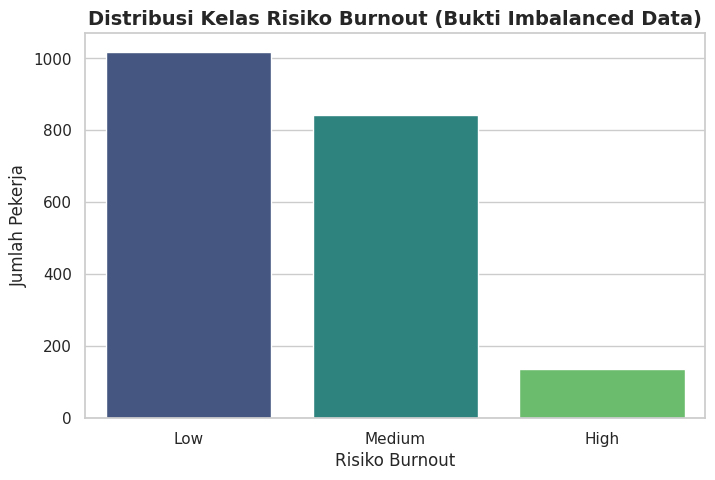

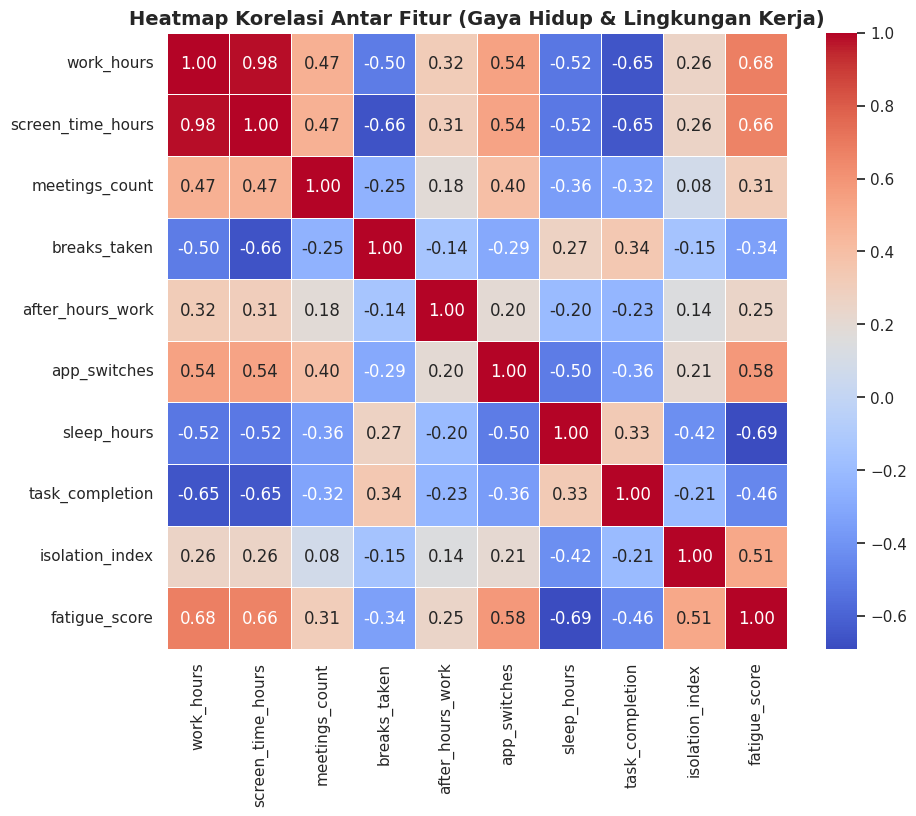

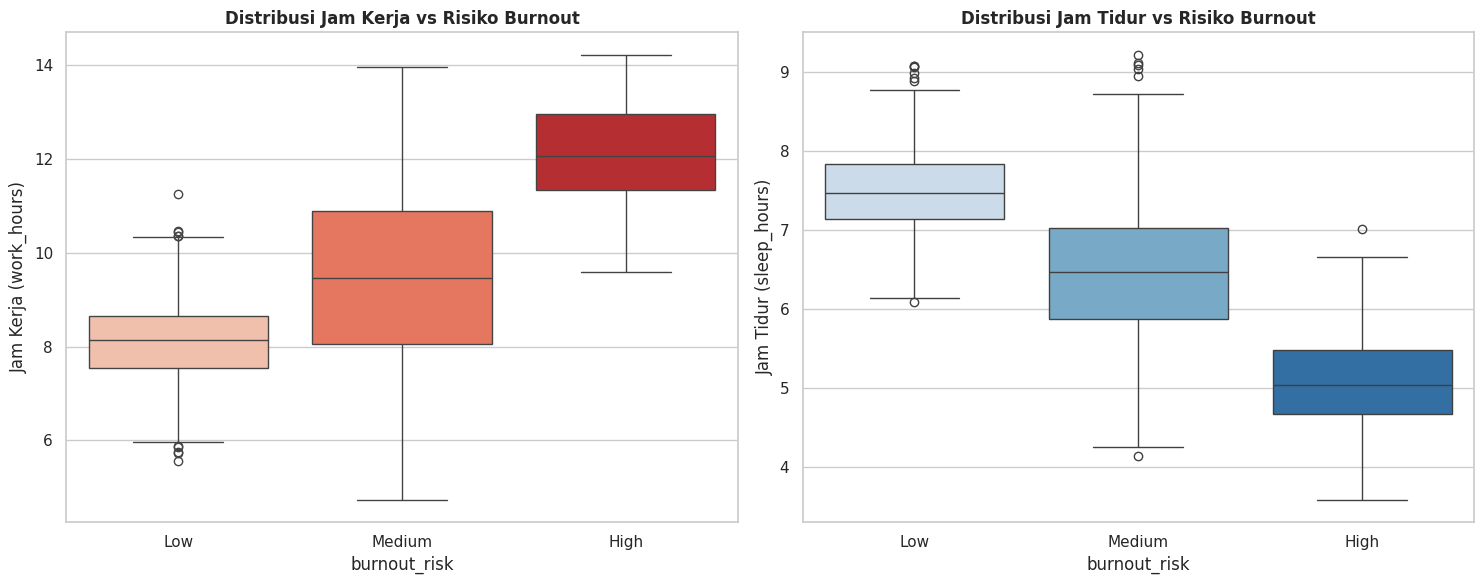

In [7]:
# Mengatur tema visualisasi
sns.set_theme(style="whitegrid")

# Visualisasi Distribusi Kelas Target
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='burnout_risk', hue='burnout_risk', order=['Low', 'Medium', 'High'], palette='viridis', legend=False)
plt.title("Distribusi Kelas Risiko Burnout (Bukti Imbalanced Data)", fontsize=14, fontweight='bold')
plt.ylabel("Jumlah Pekerja")
plt.xlabel("Risiko Burnout")
plt.show()

# Heatmap Korelasi Antar Fitur Numerik
plt.figure(figsize=(10, 8))
# Kita hanya mengambil kolom numerik untuk korelasi
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Heatmap Korelasi Antar Fitur (Gaya Hidup & Lingkungan Kerja)", fontsize=14, fontweight='bold')
plt.show()

# 3. Boxplot: Jam Kerja & Jam Tidur vs Risiko
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot Jam Kerja
sns.boxplot(ax=axes[0], data=df, x='burnout_risk', y='work_hours', hue='burnout_risk', order=['Low', 'Medium', 'High'], palette='Reds', legend=False)
axes[0].set_title("Distribusi Jam Kerja vs Risiko Burnout", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Jam Kerja (work_hours)")

# Plot Jam Tidur
sns.boxplot(ax=axes[1], data=df, x='burnout_risk', y='sleep_hours', hue='burnout_risk', order=['Low', 'Medium', 'High'], palette='Blues', legend=False)
axes[1].set_title("Distribusi Jam Tidur vs Risiko Burnout", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Jam Tidur (sleep_hours)")

plt.tight_layout()
plt.show()

### **Tahap 3: Data Preprocessing**

In [9]:
# Encoding Kolom Target (burnout_risk)
# Karena risiko memiliki tingkatan (ordinal), kita petakan manual:
risk_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['burnout_risk'] = df['burnout_risk'].map(risk_mapping)

# Encoding Fitur Kategorikal (day_type)
# Menggunakan One-Hot Encoding (pd.get_dummies)
df = pd.get_dummies(df, columns=['day_type'], drop_first=True)

# Memisahkan Fitur (X) dan Target (y)
X = df.drop('burnout_risk', axis=1)
y = df['burnout_risk']

# Feature Scaling (Standarisasi)
scaler = StandardScaler()
# Kita fit dan transform semua fitur di X
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("=== DATA X SETELAH PREPROCESSING (SCALING & ENCODING) ===")
display(X_scaled.head())

print("\n=== BENTUK DATA SEKARANG ===")
print(f"Jumlah Baris: {X_scaled.shape[0]}, Jumlah Kolom Fitur: {X_scaled.shape[1]}")

=== DATA X SETELAH PREPROCESSING (SCALING & ENCODING) ===


,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,app_switches,sleep_hours,task_completion,isolation_index,fatigue_score,day_type_Weekend
0,-0.705422,-0.857168,-0.253465,1.097616,-0.430739,-0.254278,0.615160,-0.416411,-0.528812,-1.375803,-0.627478
1,-0.276134,-0.231754,-0.253465,-0.037457,-0.430739,0.294326,0.422001,0.493438,-0.528812,-0.636227,-0.627478
2,-0.328345,-0.277147,-0.949321,-0.037457,-0.430739,-1.224884,-0.167641,0.719326,1.887235,0.581368,1.593682
3,2.044343,2.290078,0.094462,-2.307605,2.321589,1.391532,-0.350634,-1.229451,0.075199,1.550933,-0.627478
4,-0.061490,-0.171230,0.094462,0.530079,-0.430739,-0.676280,1.153971,1.458382,-1.132824,-1.402860,1.593682



=== BENTUK DATA SEKARANG ===
Jumlah Baris: 2000, Jumlah Kolom Fitur: 11


### **Tahap 4: Skenario Splitting & Penanganan Imbalanced Data (SMOTE)**

In [11]:
# Menyiapkan dictionary untuk menyimpan semua X dan y dari tiap skenario
data_scenarios = {}
# Menentukan rasio test size
test_sizes = {'70:30': 0.3, '80:20': 0.2, '90:10': 0.1}

# Inisialisasi algoritma SMOTE
smote = SMOTE(random_state=42)

print("=== PROSES DATA SPLITTING & SMOTE ===\n")

for name, test_size in test_sizes.items():
    # 1. Memecah Data (Splitting)
    # stratify=y wajib dipakai agar proporsi data target merata di train dan test
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=42, stratify=y
    )

    # Menyimpan jumlah data sebelum SMOTE
    dist_before = y_train.value_counts().to_dict()

    # 2. Menggunakan SMOTE HANYA pada data Training
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    # Menyimpan jumlah data sesudah SMOTE
    dist_after = y_train_smote.value_counts().to_dict()

    # 3. Memasukkan data siap pakai ke dalam dictionary
    data_scenarios[name] = {
        'X_train': X_train_smote,
        'y_train': y_train_smote,
        'X_test': X_test,  # Data test dibiarkan murni, TANPA SMOTE
        'y_test': y_test
    }

    # 4. Cetak laporan untuk melihat keajaiban SMOTE
    print(f"--- Skenario {name} ---")
    print(f"Distribusi Target (Train) Sebelum SMOTE : {dist_before}")
    print(f"Distribusi Target (Train) Sesudah SMOTE : {dist_after}")
    print(f"Jumlah Data Test murni                  : {len(y_test)} baris\n")

print("Tahap 4 Selesai! Data siap dimasukkan ke dalam Model Machine Learning.")

=== PROSES DATA SPLITTING & SMOTE ===

--- Skenario 70:30 ---
Distribusi Target (Train) Sebelum SMOTE : {0: 713, 1: 590, 2: 97}
Distribusi Target (Train) Sesudah SMOTE : {0: 713, 1: 713, 2: 713}
Jumlah Data Test murni                  : 600 baris

--- Skenario 80:20 ---
Distribusi Target (Train) Sebelum SMOTE : {0: 815, 1: 674, 2: 111}
Distribusi Target (Train) Sesudah SMOTE : {0: 815, 1: 815, 2: 815}
Jumlah Data Test murni                  : 400 baris

--- Skenario 90:10 ---
Distribusi Target (Train) Sebelum SMOTE : {0: 917, 1: 759, 2: 124}
Distribusi Target (Train) Sesudah SMOTE : {0: 917, 1: 917, 2: 917}
Jumlah Data Test murni                  : 200 baris

Tahap 4 Selesai! Data siap dimasukkan ke dalam Model Machine Learning.


### **Tahap 5 (Model Building & Hyperparameter Tuning)**

In [13]:
# Inisialisasi Model Dasar

models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'KNN': KNeighborsClassifier()
}

# Mendefinisikan Ruang Pencarian Parameter (Grid)

param_grids = {
    'Random Forest': {
        'n_estimators': [50, 100],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    },
    'SVM': {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf']
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance']
    }
}

# Dictionary untuk menampung seluruh hasil prediksi untuk Tahap 6
best_models_results = {}

print("=== TAHAP 5: MODEL TRAINING & HYPERPARAMETER TUNING ===")
print("Memulai proses... (Mesin sedang berpikir, harap tunggu sekitar 1-2 menit)\n")
start_time = time.time()

# Looping Utama: Skenario Data -> Model -> Tuning

for scenario_name, data in data_scenarios.items():
    print(f"--- Memproses Data Splitting {scenario_name} ---")
    best_models_results[scenario_name] = {}

    # Memanggil data yang sudah kita siapkan di tahap sebelumnya
    X_train, y_train = data['X_train'], data['y_train']
    X_test, y_test = data['X_test'], data['y_test']

    for model_name in models.keys():
        # Setup Grid Search dengan Cross-Validation (cv=3)
        grid_search = GridSearchCV(
            estimator=models[model_name],
            param_grid=param_grids[model_name],
            cv=3,
            n_jobs=-1,
            scoring='accuracy'
        )

        # A. Melatih model dengan data Training (Yang sudah di-SMOTE)
        grid_search.fit(X_train, y_train)

        # Mengambil model dengan parameter paling juara
        best_model = grid_search.best_estimator_

        # B. Menguji model dengan data Testing (Murni, TANPA SMOTE)
        y_pred = best_model.predict(X_test)

        # C. Menghitung Akurasi Dasar
        acc = accuracy_score(y_test, y_pred)

        # D. Menyimpan hasil prediksi dan model untuk laporan
        best_models_results[scenario_name][model_name] = {
            'best_params': grid_search.best_params_,
            'y_pred': y_pred,
            'y_test': y_test,
            'accuracy': acc
        }

        print(f"[{model_name}] Akurasi: {acc*100:.2f}% | Parameter Terbaik: {grid_search.best_params_}")
    print("-" * 60)

end_time = time.time()
print(f"\nTAHAP 5 SELESAI! Total Waktu Eksekusi: {(end_time - start_time):.2f} detik.")

=== TAHAP 5: MODEL TRAINING & HYPERPARAMETER TUNING ===
Memulai proses... (Mesin sedang berpikir, harap tunggu sekitar 1-2 menit)

--- Memproses Data Splitting 70:30 ---
[Random Forest] Akurasi: 96.50% | Parameter Terbaik: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
[SVM] Akurasi: 97.17% | Parameter Terbaik: {'C': 10, 'kernel': 'rbf'}
[KNN] Akurasi: 91.17% | Parameter Terbaik: {'n_neighbors': 3, 'weights': 'distance'}
------------------------------------------------------------
--- Memproses Data Splitting 80:20 ---
[Random Forest] Akurasi: 97.25% | Parameter Terbaik: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
[SVM] Akurasi: 99.25% | Parameter Terbaik: {'C': 10, 'kernel': 'linear'}
[KNN] Akurasi: 91.50% | Parameter Terbaik: {'n_neighbors': 3, 'weights': 'distance'}
------------------------------------------------------------
--- Memproses Data Splitting 90:10 ---
[Random Forest] Akurasi: 97.00% | Parameter Terbaik: {'max_depth': None, 'min_sam

### **Tahap 6: Evaluasi & Model Comparison.**

=== TAHAP 6: EVALUASI & KOMPARASI MODEL ===

Tabel Perbandingan Akurasi Keseluruhan:


,Skenario (Train:Test),Algoritma,Akurasi (%)
0,80:20,SVM,99.250000
1,90:10,SVM,99.000000
2,80:20,Random Forest,97.250000
3,70:30,SVM,97.166667
4,90:10,Random Forest,97.000000
5,70:30,Random Forest,96.500000
6,90:10,KNN,93.000000
7,80:20,KNN,91.500000
8,70:30,KNN,91.166667




=== LAPORAN EVALUASI DETAIL: SVM (Skenario 80:20) ===
              precision    recall  f1-score   support

         Low       0.99      1.00      0.99       204
      Medium       1.00      0.98      0.99       169
        High       1.00      1.00      1.00        27

    accuracy                           0.99       400
   macro avg       1.00      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



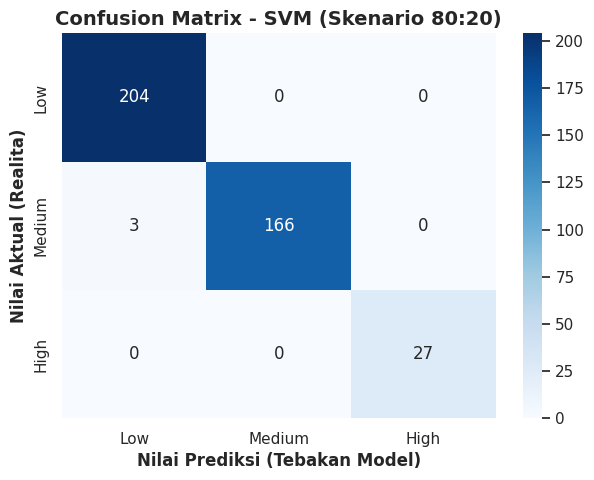

In [15]:
print("=== TAHAP 6: EVALUASI & KOMPARASI MODEL ===\n")

# Membuat Tabel Komparasi Semua Model

comparison_data = []

for scenario, models_dict in best_models_results.items():
    for model_name, result in models_dict.items():
        comparison_data.append({
            'Skenario (Train:Test)': scenario,
            'Algoritma': model_name,
            'Akurasi (%)': result['accuracy'] * 100
        })

df_comparison = pd.DataFrame(comparison_data)
# Mengurutkan dari akurasi tertinggi ke terendah
df_comparison = df_comparison.sort_values(by='Akurasi (%)', ascending=False).reset_index(drop=True)

print("Tabel Perbandingan Akurasi Keseluruhan:")
display(df_comparison)

# Evaluasi Mendalam Model Terbaik (SVM 80:20)
# Mengambil hasil prediksi dari SVM skenario 80:20
best_scenario = '80:20'
best_algo = 'SVM'

y_test_best = best_models_results[best_scenario][best_algo]['y_test']
y_pred_best = best_models_results[best_scenario][best_algo]['y_pred']

print(f"\n\n=== LAPORAN EVALUASI DETAIL: {best_algo} (Skenario {best_scenario}) ===")

print(classification_report(y_test_best, y_pred_best, target_names=['Low', 'Medium', 'High']))

# Visualisasi Confusion Matrix

cm = confusion_matrix(y_test_best, y_pred_best)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.title(f"Confusion Matrix - {best_algo} (Skenario {best_scenario})", fontsize=14, fontweight='bold')
plt.ylabel('Nilai Aktual (Realita)', fontweight='bold')
plt.xlabel('Nilai Prediksi (Tebakan Model)', fontweight='bold')
plt.show()

### **TAHAP 7: MODEL INFERENCE**

In [32]:
# 1. Membuat Data Baru
pekerja_baru = pd.DataFrame({
    'Nama': ['Budi', 'Siti'],
    'day_type': ['Weekday', 'Weekday'],
    'work_hours': [8.0, 14.5],             # Budi 8 jam, Siti 14.5 jam
    'screen_time_hours': [6.0, 13.0],      # Waktu menatap layar
    'meetings_count': [1, 7],              # Jumlah meeting
    'breaks_taken': [4, 0],                # Siti tidak pernah istirahat
    'after_hours_work': [0, 5],            # Siti lembur 5 jam
    'app_switches': [15, 45],              # Tingkat multitasking (distraksi)
    'sleep_hours': [8.0, 4.0],             # Budi tidur 8 jam, Siti 4 jam
    'task_completion': [95.0, 40.0],       # Persentase tugas selesai
    'isolation_index': [1, 9],             # Siti merasa sangat terisolasi
    'fatigue_score': [1.5, 9.8]            # Skor kelelahan (0-10)
})

print("=== DATA PROFIL PEKERJA BARU ===")
display(pekerja_baru)

# 2. Preprocessing Data Baru
data_inference = pekerja_baru.copy().drop('Nama', axis=1)

# A. Manual One-Hot Encoding untuk 'day_type' agar sesuai format X_train
data_inference['day_type_Weekend'] = data_inference['day_type'].apply(lambda x: 1 if x == 'Weekend' else 0)
data_inference = data_inference.drop('day_type', axis=1)

# Memastikan urutan kolom sama persis dengan urutan kolom saat model di-training
data_inference = data_inference[X.columns]

# B. Scaling menggunakan 'scaler' yang sudah di-fit di Tahap 3
data_inference_scaled = pd.DataFrame(scaler.transform(data_inference), columns=X.columns)

# 3. Melatih ulang model SVM terbaik dengan parameter pemenang (Skenario 80:20)
# Ini memastikan kita memegang objek model secara langsung
final_model = SVC(C=10, kernel='linear', random_state=42)
final_model.fit(data_scenarios['80:20']['X_train'], data_scenarios['80:20']['y_train'])

# 4. Melakukan Prediksi (Inference)
prediksi_angka = final_model.predict(data_inference_scaled)

# 5. Menerjemahkan angka kembali ke teks (0='Low', 1='Medium', 2='High')
kamus_risiko = {0: 'Low', 1: 'Medium', 2: 'High'}
hasil_prediksi = [kamus_risiko[angka] for angka in prediksi_angka]

# Menampilkan Hasil Akhir
pekerja_baru['PREDIKSI RISIKO BURNOUT'] = hasil_prediksi

print("\n=== HASIL INFERENCE OLEH MODEL SVM TERBAIK ===")
display(pekerja_baru[['Nama', 'work_hours', 'sleep_hours', 'fatigue_score', 'PREDIKSI RISIKO BURNOUT']])

=== DATA PROFIL PEKERJA BARU ===


,Nama,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,app_switches,sleep_hours,task_completion,isolation_index,fatigue_score
0,Budi,Weekday,8.0,6.0,1,4,0,15,8.0,95.0,1,1.5
1,Siti,Weekday,14.5,13.0,7,0,5,45,4.0,40.0,9,9.8



=== HASIL INFERENCE OLEH MODEL SVM TERBAIK ===


,Nama,work_hours,sleep_hours,fatigue_score,PREDIKSI RISIKO BURNOUT
0,Budi,8.0,8.0,1.5,Low
1,Siti,14.5,4.0,9.8,High
